In [42]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Data Understanding

In [2]:
crop_Data=pd.read_csv("data/Crop_recommendation.csv")

In [35]:
corr_anylise.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [32]:
crop_Data["label"].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [5]:
crop_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


# Model Building

In [52]:
X=crop_Data.drop("label",axis=1)
Y=crop_Data["label"]


In [53]:


le = LabelEncoder()
y_encoded = le.fit(Y)


In [54]:



X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42,
    stratify=Y
)


In [55]:
y_train_Encoded=le.transform(y_train)
y_test_Encoded=le.transform(y_test)

In [57]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

 

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42
)
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",   # for multiclass
    eval_metric="mlogloss",
    random_state=42
)

# MODEL EVALUATION

In [58]:
from sklearn.metrics import accuracy_score, classification_report



def evaluate_model(model, X_train, X_test, y_train, y_test):
    print(f"Model Name:{model}")
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print("Train Accuracy:",100* accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))


In [59]:
evaluate_model(rf, X_train, X_test, y_train_Encoded, y_test_Encoded)
evaluate_model(xgb, X_train, X_test, y_train_Encoded, y_test_Encoded)
evaluate_model(gb, X_train, X_test, y_train_Encoded, y_test_Encoded)


Model Name:RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
Train Accuracy: 100.0
Test Accuracy: 0.9939393939393939

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30
           2       1.00      0.97      0.98        30
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        30
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        30
           8       0.94      1.00      0.97        30
           9       1.00      1.00      1.00        30
          10       1.00      0.97      0.98        30
          11       0.97      1.00      0.98        30
          12       1.00      1.00      1.00        30
          13       0.97      1.00      0.98        30
          14       1.00      

       feature  importance
6     rainfall    0.219465
4     humidity    0.209029
2            K    0.175356
1            P    0.152108
0            N    0.110974
3  temperature    0.078339
5           ph    0.054729


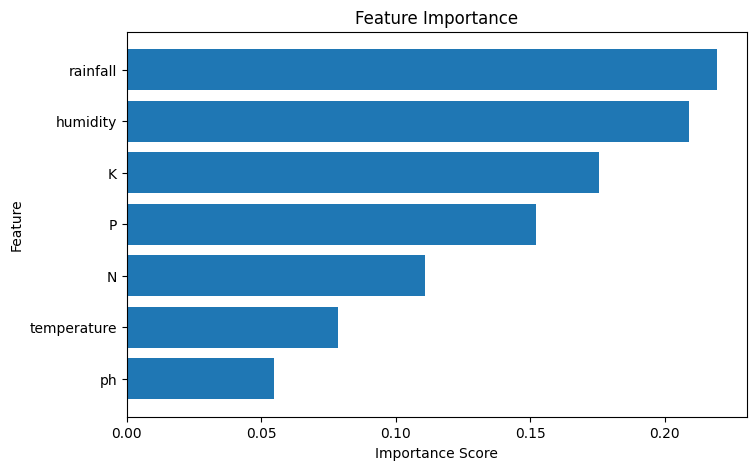

In [62]:
#If you try before which full crop data set the temperature and ph feature are very low so i have removed because model take mode time and space but same accuracy
feature_names = X_train.columns  
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


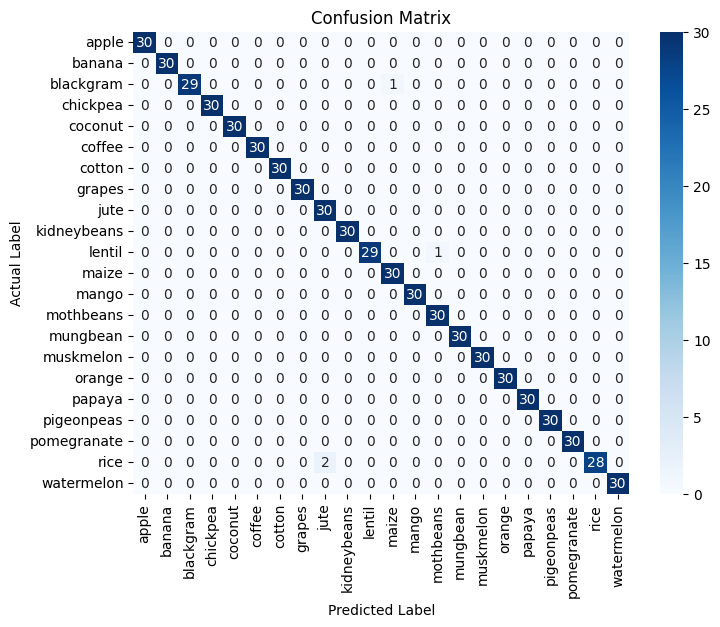

In [63]:
y_pred=rf.predict(X_test)
cm = confusion_matrix(y_test_Encoded, y_pred)

plt.figure(figsize=(8, 6))
class_names = le.classes_
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


# Predicting Sample Data

In [40]:
def predict_crop(model,data):
    predict=model.predict(data)
    output=le.inverse_transform(predict)
    return output
Sample_data=[[90,42,43,82.0,202.9]]
Sample_data_df=pd.DataFrame(Sample_data)
predict_crop(rf,Sample_data_df)

C:\Users\G naveen kumar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array(['rice'], dtype=object)

In [131]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X_train,
    y_train_Encoded,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())


CV Scores: [0.99675325 0.99025974 0.99350649 0.98701299 0.98701299]
Mean Accuracy: 0.9909090909090909
Std Dev: 0.003786332399250194


# Selected The RandomForestClassifier Model Which Perform Well For This Project
